/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


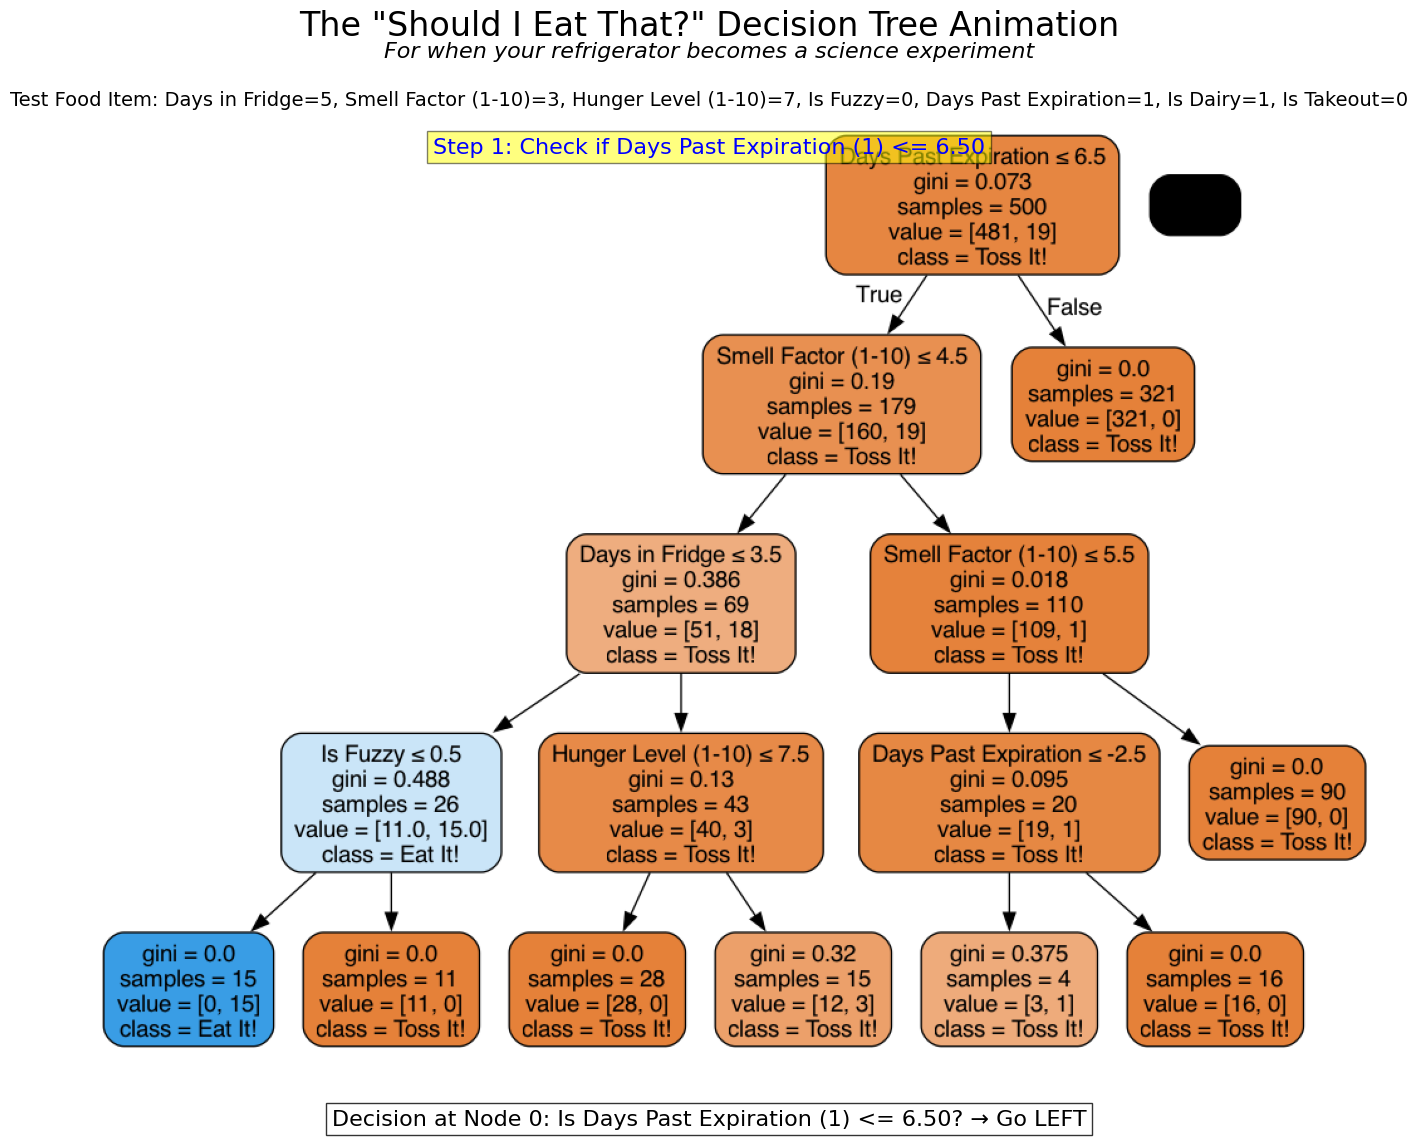

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import pydotplus
from PIL import Image
from io import BytesIO

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data about questionable food items
n_samples = 500

# Features:
days_in_fridge = np.random.randint(0, 14, n_samples)  # 0-14 days
smell_factor = np.random.randint(1, 11, n_samples)   # 1-10 scale (10 is terrible)
how_hungry = np.random.randint(1, 11, n_samples)     # 1-10 scale (10 is starving)
fuzzy = np.random.randint(0, 2, n_samples)           # 0=no, 1=yes
expired_days = np.random.randint(-5, 30, n_samples)  # days past expiration (-5 means still good)
is_dairy = np.random.randint(0, 2, n_samples)        # 0=no, 1=yes
is_takeout = np.random.randint(0, 2, n_samples)      # 0=no, 1=yes

# Decision rules for whether to eat or not
should_eat = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    # Instant no if fuzzy
    if fuzzy[i] == 1:
        should_eat[i] = 0  # Don't eat!
    # Very stinky food is a no
    elif smell_factor[i] >= 8:
        should_eat[i] = 0  # Don't eat!
    # Dairy products are risky after few days
    elif is_dairy[i] == 1 and days_in_fridge[i] > 5:
        should_eat[i] = 0  # Don't eat!
    # Significantly expired food is a no
    elif expired_days[i] > 7:
        should_eat[i] = 0  # Don't eat!
    # Takeout gets questionable quickly
    elif is_takeout[i] == 1 and days_in_fridge[i] > 3:
        should_eat[i] = 0  # Don't eat!
    # If very hungry, risks increase
    elif how_hungry[i] >= 8:
        # Even hungry people have limits
        if smell_factor[i] >= 6 or fuzzy[i] == 1:
            should_eat[i] = 0  # Don't eat!
        else:
            should_eat[i] = 1  # Eat it!
    # General rule: fresh enough is okay
    elif days_in_fridge[i] <= 3 and smell_factor[i] <= 4:
        should_eat[i] = 1  # Eat it!
    # When in doubt, don't eat it
    else:
        should_eat[i] = 0  # Don't eat!

# Create a DataFrame
data = pd.DataFrame({
    'Days in Fridge': days_in_fridge,
    'Smell Factor (1-10)': smell_factor,
    'Hunger Level (1-10)': how_hungry,
    'Is Fuzzy': fuzzy,
    'Days Past Expiration': expired_days,
    'Is Dairy': is_dairy,
    'Is Takeout': is_takeout,
    'Should Eat': should_eat
})

# Prepare features and target
X = data.drop('Should Eat', axis=1)
y = data['Should Eat']

# Train a decision tree with limited depth for better visualization
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

# Extract tree info
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
values = clf.tree_.value

# Create a function to trace through the decision tree for a test sample
def trace_decision_path(sample, clf, X):
    feature_names = X.columns
    node_indicator = clf.decision_path([sample]).toarray()[0]
    leaf_id = clf.apply([sample])[0]
    
    # Get the decision path
    path_nodes = np.where(node_indicator > 0)[0]
    
    # Get feature values for the sample
    test_sample_values = {feature_names[i]: sample[i] for i in range(len(feature_names))}
    
    # Prepare a list to store the decision process
    decision_process = []
    
    # For each node in the path
    for i, node_id in enumerate(path_nodes):
        # If we're not at a leaf node
        if node_id != leaf_id:
            # Get the feature and threshold for this decision
            feature_id = feature[node_id]
            feature_name = feature_names[feature_id]
            feature_value = sample[feature_id]
            feature_threshold = threshold[node_id]
            
            # Determine which way we go in the tree
            if feature_value <= feature_threshold:
                decision = "<="
                next_node = children_left[node_id]
            else:
                decision = ">"
                next_node = children_right[node_id]
            
            decision_process.append({
                'step': i+1,
                'node_id': node_id,
                'feature': feature_name,
                'value': feature_value,
                'threshold': feature_threshold,
                'decision': decision,
                'next_node': next_node
            })
    
    # Add the final classification
    leaf_values = values[leaf_id][0]
    prediction = "Eat It!" if leaf_values[1] > leaf_values[0] else "Toss It!"
    
    decision_process.append({
        'step': len(path_nodes),
        'node_id': leaf_id,
        'prediction': prediction
    })
    
    return path_nodes, decision_process, test_sample_values, prediction

# Create a test case
test_case = [
    5,      # Days in Fridge
    3,      # Smell Factor
    7,      # Hunger Level
    0,      # Is Fuzzy (No)
    1,      # Days Past Expiration
    1,      # Is Dairy (Yes)
    0       # Is Takeout (No)
]

# Get the decision path for our test case
path_nodes, decision_process, test_sample_values, prediction = trace_decision_path(test_case, clf, X)

# Set up the figure for animation
plt.figure(figsize=(20, 12))

# Animation function
def update(frame):
    plt.clf()  # Clear figure for fresh plotting

    # Title and test case details
    plt.suptitle('The "Should I Eat That?" Decision Tree Animation', fontsize=24, y=0.98)
    plt.figtext(0.5, 0.94, 'For when your refrigerator becomes a science experiment', 
                ha='center', fontsize=16, style='italic')

    test_case_str = "Test Food Item: " + ", ".join(f"{k}={v}" for k, v in test_sample_values.items())
    plt.figtext(0.5, 0.90, test_case_str, ha='center', fontsize=14)

    # Validate frame index
    if frame >= len(decision_process):
        frame = len(decision_process) - 1  # Prevent out-of-bounds access

    # Display decision step
    step_info = decision_process[frame]
    if 'prediction' in step_info:
        step_text = f"Final Decision: {step_info['prediction']}"
        color = "green" if step_info['prediction'] == "Eat It!" else "red"
    else:
        step_text = (f"Step {step_info['step']}: Check if {step_info['feature']} "
                     f"({step_info['value']}) {step_info['decision']} {step_info['threshold']:.2f}")
        color = "blue"

    plt.figtext(0.5, 0.86, step_text, ha='center', fontsize=16, 
                bbox=dict(facecolor='yellow', alpha=0.5), color=color)

    # Validate path_nodes index
    current_path = path_nodes[:frame + 1] if frame < len(path_nodes) else path_nodes

    # Highlight nodes and edges using Graphviz
    dot_data = export_graphviz(
        clf, 
        out_file=None, 
        feature_names=X.columns, 
        class_names=['Toss It!', 'Eat It!'], 
        filled=True, 
        rounded=True, 
        special_characters=True
    )

    graph = pydotplus.graph_from_dot_data(dot_data)

    # Modify node colors for path highlighting
    for node in current_path:
        if str(node) in graph.get_node(str(node)):  # Ensure node exists
            graph.get_node(str(node))[0].set_fillcolor("lightblue")

    # Modify edge colors along the path
    if len(current_path) > 1:
        for i in range(len(current_path) - 1):
            src, dest = str(current_path[i]), str(current_path[i+1])
            for edge in graph.get_edges():
                if edge.get_source() == src and edge.get_destination() == dest:
                    edge.set_color("red")
                    edge.set_penwidth(3)

    # Convert GraphViz output to image
    img = Image.open(BytesIO(graph.create_png()))

    # Display the decision tree
    plt.imshow(img)
    plt.axis('off')

    # Add footer for final decision
    if 'prediction' in step_info:
        footer_text = f"Final Decision: {step_info['prediction']}"
        footer_color = "green" if step_info['prediction'] == "Eat It!" else "red"
        plt.figtext(0.5, 0.05, footer_text, ha='center', fontsize=20, 
                    bbox=dict(facecolor='yellow', alpha=0.8), color=footer_color)
    else:
        left_or_right = "LEFT" if step_info['decision'] == "<=" else "RIGHT"
        decision_text = (f"Decision at Node {step_info['node_id']}: "
                         f"Is {step_info['feature']} ({step_info['value']}) {step_info['decision']} "
                         f"{step_info['threshold']:.2f}? → Go {left_or_right}")
        plt.figtext(0.5, 0.05, decision_text, ha='center', fontsize=16, 
                    bbox=dict(facecolor='white', alpha=0.8))

    return plt.gcf()

# Create the animation
ani = FuncAnimation(plt.gcf(), update, frames=len(decision_process), interval=1500, repeat=True)

# Save the animation if needed (uncomment this)
ani.save('decision_tree_animation.gif', writer='pillow', fps=1)

# To run in Jupyter, use:
from IPython.display import HTML
HTML(ani.to_jshtml())

